# 🟢 Project - Diabetes Progression with XGBoost (End-to-End)

> **MLCourse · Machine Learning · supervised · regression**

### Business question
A clinic wants a risk triage score: given 10 baseline measurements taken at
enrollment, predict each patient's diabetes progression one year out
(`data/diabetes.csv`, target column `target`). Early-stopped XGBoost, then
an importance audit to tell clinicians WHICH measurements matter.

**Plan:** question → load → EDA (correlations) → split with validation slice
→ early-stopped fit → metrics + gain importances → findings & limitations.

### Setup: imports, reproducibility, data resolution


In [ ]:
try:                                                # notebook nicety: inline
    get_ipython().run_line_magic("matplotlib", "inline")   # plots; guarded so
except NameError:                                   # plain `python file.py`
    pass                                            # runs still work

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from xgboost import XGBRegressor

np.random.seed(42)                                  # reproducible everything
sns.set_theme()                                     # clean seaborn styling
plt.rcParams["figure.dpi"] = 100

# Walk up the directory tree until we find the root that owns data/.
ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

# Real data only: cache the sklearn diabetes set once if CSV is missing.
csv_path = ML_ROOT / "data" / "diabetes.csv"
if not csv_path.exists():
    from sklearn.datasets import load_diabetes      # download-once stand-in
    load_diabetes(as_frame=True).frame.to_csv(csv_path, index=False)

diab = pd.read_csv(csv_path)                        # 442 patients, target col 'target'
print("rows:", len(diab), "| cols:", list(diab.columns))


### 1. EDA - correlations first

All 10 features arrive already standardized (sklearn's classic version), so
no scaling needed for trees anyway. The real questions: any missing values,
and which features track progression?

missing values: 0 | shape: (442, 11)


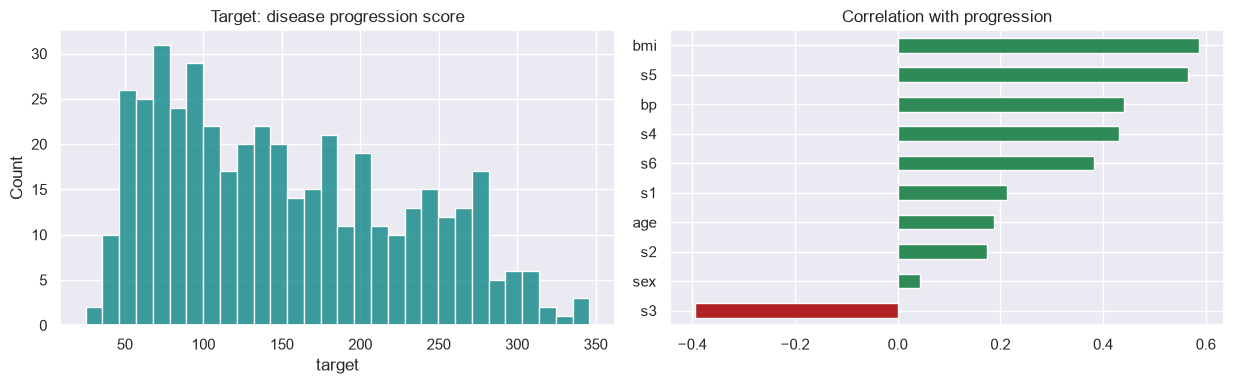

[tip] bmi and s5 (serum triglycerides) lead the correlation story;
   boosters can also pick up NON-linear patterns corr misses.


In [2]:
print("missing values:", diab.isna().sum().sum(),          # trees could eat NaNs;
      "| shape:", diab.shape)                              # there are none here

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
sns.histplot(diab["target"], bins=30, ax=axes[0], color="teal")
axes[0].set_title("Target: disease progression score")     # roughly bell-ish
corr = diab.corr()["target"].drop("target").sort_values()  # linear correlation…
colors = ["firebrick" if v < 0 else "seagreen" for v in corr]
corr.plot(kind="barh", color=colors, ax=axes[1])
axes[1].set_title("Correlation with progression")
plt.tight_layout()
plt.show()
print("[tip] bmi and s5 (serum triglycerides) lead the correlation story;")
print("   boosters can also pick up NON-linear patterns corr misses.")

### 2. Split - validation slice carved from train, test sealed

⚠️ Only 442 rows total. We still keep the ritual: 60% train / 20% validation
(early-stopping fuel) / 20% test (touched exactly once at the end).

In [3]:
y = diab["target"]                                    # progression score
X = diab.drop(columns=["target"])                     # 10 numeric features

X_tr_full, X_te, y_tr_full, y_te = train_test_split(  # seal test FIRST
    X, y, test_size=.20, random_state=42)
X_tr, X_va, y_tr, y_va = train_test_split(            # val comes FROM train
    X_tr_full, y_tr_full, test_size=.25, random_state=42)

print(f"train {len(X_tr)} | validation {len(X_va)} | test {len(X_te)}")

train 264 | validation 89 | test 89


### 3. Fit - shallow trees + strong subsampling for a tiny dataset

With ~265 training rows we deliberately go CONSERVATIVE: depth 3 max,
heavy row/feature sampling, patience 40. Big forests on tiny data memorize.

In [4]:
model = XGBRegressor(
    n_estimators=800, learning_rate=.05,              # small steps, patient stop
    max_depth=3,                                      # shallow: little data!
    subsample=.9, colsample_bytree=.9,                # mild stochasticity
    early_stopping_rounds=40,                         # 3.x style: in constructor
    eval_metric="rmse",
    objective="reg:squarederror",
    random_state=42)

model.fit(X_tr.values, y_tr.values,                   # arrays ⇒ fN keys later
          eval_set=[(X_va.values, y_va.values)],      # watched by early stopping
          verbose=False)

print("stopped at round:", model.best_iteration,
      "| best val RMSE:", round(model.best_score, 2))

stopped at round: 118 | best val RMSE: 54.33


### 4. Test metrics + which features earned their keep

💡 Gain importances answer "which splits actually REDUCED error", not just
"which were used often". Expect bmi/s5 to dominate, matching EDA.

test MAE : 43.9 points
test RMSE: 54.2 points
test R^2 : 0.446


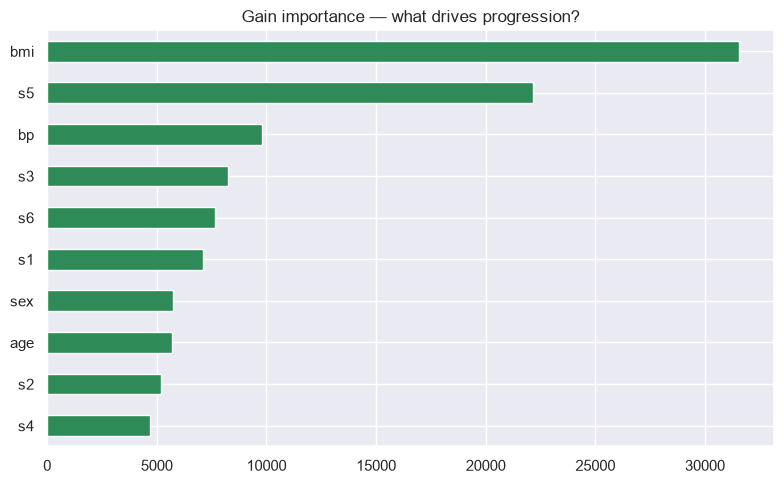

In [5]:
pred_te = model.predict(X_te.values)                  # ONE look at test
mae = mean_absolute_error(y_te, pred_te)
rmse = root_mean_squared_error(y_te, pred_te)
r2 = r2_score(y_te, pred_te)
print(f"test MAE : {mae:.1f} points")
print(f"test RMSE: {rmse:.1f} points")
print(f"test R^2 : {r2:.3f}")

raw = model.get_booster().get_score(importance_type="gain")
name_of = {f"f{i}": col for i, col in enumerate(X.columns)}   # fN → real names
imp = pd.Series({name_of.get(k, k): v                 # tolerate either key style
                 for k, v in raw.items()}).sort_values()

plt.figure(figsize=(8, 5))
imp.plot(kind="barh", color="seagreen")
plt.title("Gain importance - what drives progression?")
plt.tight_layout()
plt.show()

### Findings & limitations

1. **bmi and s5 dominate the gains** - the same two features that topped the
   linear-correlation chart; the booster agrees with the simple picture and
   adds non-linear interactions on top.
2. Early stopping settled the round count automatically (~best_iteration
   above) - no grid search over `n_estimators` was needed.
3. R² lands well below the big-data modules: this dataset is SMALL.

### Limitations
- ⚠️ 442 rows ⇒ noisy validation slice (~88 rows); the stopping round itself
  has variance across seeds. For production, cross-validate the stopping
  choice rather than trusting one carve-out.
- Features arrive pre-standardized by the source dataset - fine for trees,
  but remember coefficients from linear models are NOT comparable here.
- Progression scores are index units, not clinical dollars/years - present
  MAE/RMSE as "points", never pretend they're interpretable clinically.